In [ ]:
from rbfPUCurlNoise.triang_mesh          import TriMesh, refine_mesh_1to4
from rbfPUCurlNoise.patches       import PatchCoverage
from rbfPUCurlNoise.rbf           import RBF
from rbfPUCurlNoise.interpolator  import PUMInterpolator
from rbfPUCurlNoise.visualization import plot_patches, plot_combined_field
from rbfPUCurlNoise.potential import NoisePotential2D
from rbfPUCurlNoise.utils import plot_noise_mesh, plot_mesh, plot_layers_mesh, refine_around_brder
from perlin_noise import PerlinNoise
import triangle
import numpy as np

In [5]:
noise_seed = 7
noise = PerlinNoise(octaves=3, seed=noise_seed)

## alienbs

In [6]:
alienbs = triangle.load("..\\meshes\\triangle_files", "alienbs")
alienbs_mesh = triangle.triangulate(alienbs, "pq30a150")

print(alienbs_mesh["vertices"].min(), alienbs_mesh["vertices"].max())
mins = alienbs_mesh["vertices"].min(axis=0)
maxs = alienbs_mesh["vertices"].max(axis=0)


# Normalizing mesh vertices range
alienbs_mesh["vertices"] = 2 * (alienbs_mesh["vertices"] - mins) / (maxs - mins) - 1
print(alienbs_mesh["vertices"].min(), alienbs_mesh["vertices"].max())

alienbs_mesh_obj = TriMesh(alienbs_mesh)

#plot_mesh(alienbs_mesh)

-1001.81 828.5
-1.0 1.0


In [7]:
alienbs_mesh_obj.sdf_distance_to_segments_min()

sdf = alienbs_mesh_obj.get_sdf_field()
clst_pts = alienbs_mesh_obj.get_closest_pts()
freq = 2
mesh_noise = alienbs_mesh_obj.generate_mesh_noise_scalar_field(noise, freq)

(5333,)


In [8]:
noise_clsts = []
for pt in clst_pts:
    noise_val = noise([pt[0] * freq, pt[1] * freq])
    noise_clsts.append(noise_val)

noise_clsts = np.array(noise_clsts)

coverage = PatchCoverage(alienbs_mesh_obj, H=0.2, delta=0.2, min_nodes_per_patch=4)
coverage.summary() # Resumo da cobertura

potential_sdf = NoisePotential2D(alienbs_mesh_obj, coverage, RBF(epsilon=1.0))

psi = potential_sdf.noise_potential_ramp_mult_sdf(mesh_noise, sdf, d0=0.2)


Resumo da cobertura:
  n_patches           : 88
  H                   : 0.2
  delta               : 0.2
  min_nodes           : 7
  max_nodes           : 242
  mean_nodes          : 127.125
  min_coverage        : 1
  max_coverage        : 4
  mean_coverage       : 2.0976936058503655
  full_coverage       : True
(5333,)


In [9]:
alienbs_mesh_obj.save_mesh_paraview(alienbs_mesh, phi=mesh_noise, psi=psi, sdf=sdf, out_name="alienbs_sdf_field.vtu", save_norm=True)

Normalization factor: 0.5698497112913905
Original normalized range:
-1.0 0.9985541305342412
Masked normalized range:
-0.8698812794257804 0.7053348062407971


## starfish

In [10]:
from scipy.io      import loadmat

freq = 1
data = loadmat('starfish.mat')
pts = data['X']
print(pts.min(), pts.max())
tri = data['tri'] - 1

starfish_mesh = {}
starfish_mesh["vertices"] = pts
starfish_mesh["triangles"] = tri

-1.0 1.0


In [11]:
starfish_mesh_obj = TriMesh(starfish_mesh)

freq = 1
mesh_noise = starfish_mesh_obj.generate_mesh_noise_scalar_field(noise, freq)

(1382,)

Resumo da cobertura:
  n_patches           : 75
  H                   : 0.2
  delta               : 0.2
  min_nodes           : 13
  max_nodes           : 58
  mean_nodes          : 38.93333333333333
  min_coverage        : 1
  max_coverage        : 4
  mean_coverage       : 2.1128798842257597
  full_coverage       : True
(1382,)


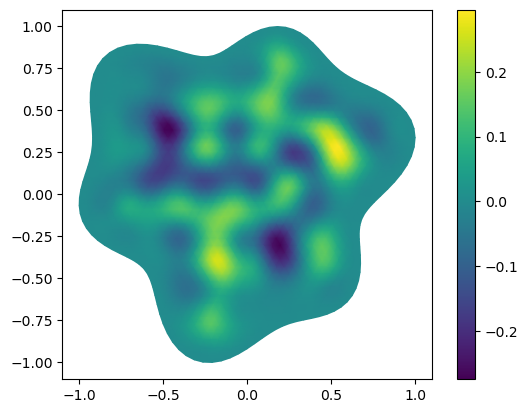

In [12]:
starfish_mesh_obj.sdf_distance_to_segments_min()
sdf = starfish_mesh_obj.get_sdf_field()
clst_pts = starfish_mesh_obj.get_closest_pts()

noise_clsts = []
for pt in clst_pts:
    noise_val = noise([pt[0] * freq, pt[1] * freq])
    noise_clsts.append(noise_val)

noise_clsts = np.array(noise_clsts)

coverage = PatchCoverage(starfish_mesh_obj, H=0.2, delta=0.2, min_nodes_per_patch=4)
coverage.summary() # Resumo da cobertura

potential_sdf = NoisePotential2D(starfish_mesh_obj, coverage, RBF(epsilon=1.0))

psi = potential_sdf.noise_potential_ramp_mult_sdf(mesh_noise, sdf, d0=0.5)
plot_noise_mesh(starfish_mesh, psi)

In [13]:
# With boundary treatment
potential_sdf.fit(psi)

grad_x, grad_y = potential_sdf.gradient(starfish_mesh["vertices"])
curl = np.hstack((grad_y.reshape(-1,1), -grad_x.reshape(-1,1)))

starfish_mesh_obj.save_mesh_paraview(starfish_mesh, vels=curl, phi=mesh_noise, psi=psi, out_name="starfish_sdf_noise.vtu", save_norm=True)

Normalization factor: 0.5665695257664094
Original normalized range:
-0.6643658986169908 1.0
Masked normalized range:
-0.4847411810701776 0.5219474368893678
